In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configuring display settings
plt.rcParams['figure.figsize'] = (12, 9)
sns.set_theme()
sns.set_context('talk')
np.set_printoptions(threshold=20, precision=2, suppress=True)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)
pd.set_option('display.float_format', '{:.2f}'.format)
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
from pathlib import Path
import pandas as pd

FILENAME= 'housing.csv'
PATH = 'data'

# Recherche du dataset depuis le dossier courant ou la racine du projet
possible_paths = [
    Path.cwd() / PATH / FILENAME,
    Path.cwd().parent / PATH / FILENAME,
]

csv_file_path = next(
    (path for path in possible_paths if path.is_file()),
    None
)

if csv_file_path is None:
    raise FileNotFoundError(
        "Dataset introuvable. Placez le fichier "
        f"'{FILENAME}' dans le dossier 'data' du projet."
    )

housing_data = pd.read_csv(str(csv_file_path))

# Display the first few rows of the dataset
housing_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.00,880.00,129.00,322.00,126.00,8.33,452600.00,NEAR BAY
1,-122.22,37.86,21.00,7099.00,1106.00,2401.00,1138.00,8.30,358500.00,NEAR BAY
2,-122.24,37.85,52.00,1467.00,190.00,496.00,177.00,7.26,352100.00,NEAR BAY
3,-122.25,37.85,52.00,1274.00,235.00,558.00,219.00,5.64,341300.00,NEAR BAY
4,-122.25,37.85,52.00,1627.00,280.00,565.00,259.00,3.85,342200.00,NEAR BAY


In [3]:
# Display basic information
housing_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [4]:
housing_data.dtypes

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object

In [5]:
housing_data.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [6]:
# Display summary statistics
housing_data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.00,20640.00,20640.00,20640.00,20433.00,20640.00,20640.00,20640.00,20640.00
mean,-119.57,35.63,28.64,2635.76,537.87,1425.48,499.54,3.87,206855.82
std,2.00,2.14,12.59,2181.62,421.39,1132.46,382.33,1.90,115395.62
min,-124.35,32.54,1.00,2.00,1.00,3.00,1.00,0.50,14999.00
25%,-121.80,33.93,18.00,1447.75,296.00,787.00,280.00,2.56,119600.00
50%,-118.49,34.26,29.00,2127.00,435.00,1166.00,409.00,3.53,179700.00
75%,-118.01,37.71,37.00,3148.00,647.00,1725.00,605.00,4.74,264725.00
max,-114.31,41.95,52.00,39320.00,6445.00,35682.00,6082.00,15.00,500001.00


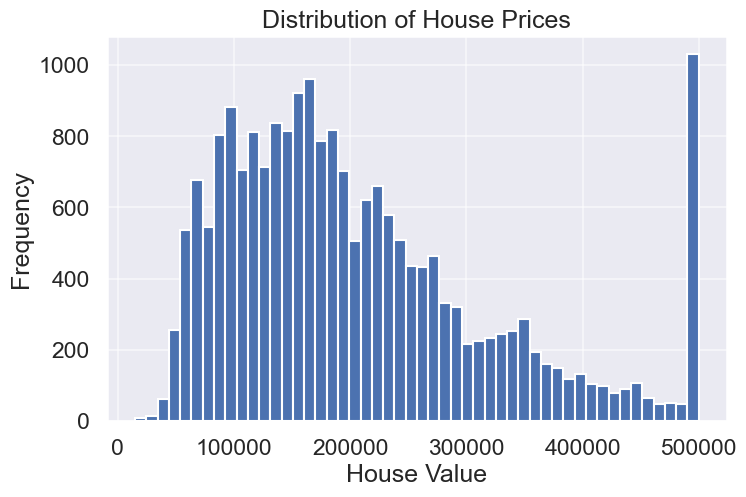

In [7]:
plt.figure(figsize=(8,5))
plt.hist(housing_data["median_house_value"], bins=50)
plt.xlabel("House Value")
plt.ylabel("Frequency")
plt.title("Distribution of House Prices")
plt.show()

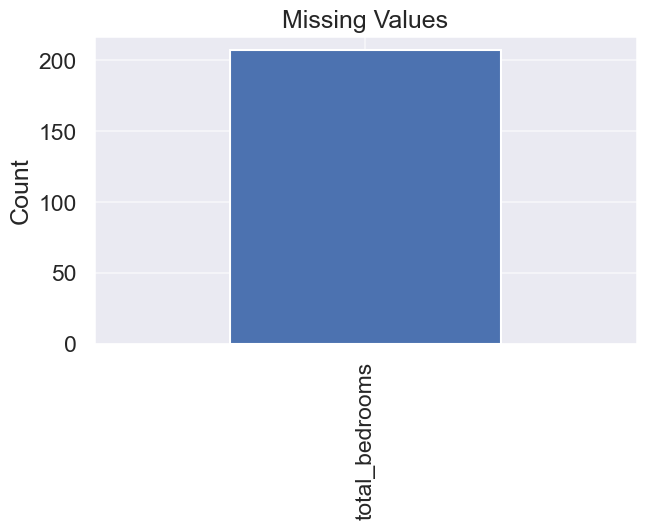

In [8]:
missing = housing_data.isnull().sum()
missing = missing[missing > 0]

missing.plot(kind="bar", figsize=(7,4))
plt.title("Missing Values")
plt.ylabel("Count")
plt.show()

In [9]:
housing_data["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

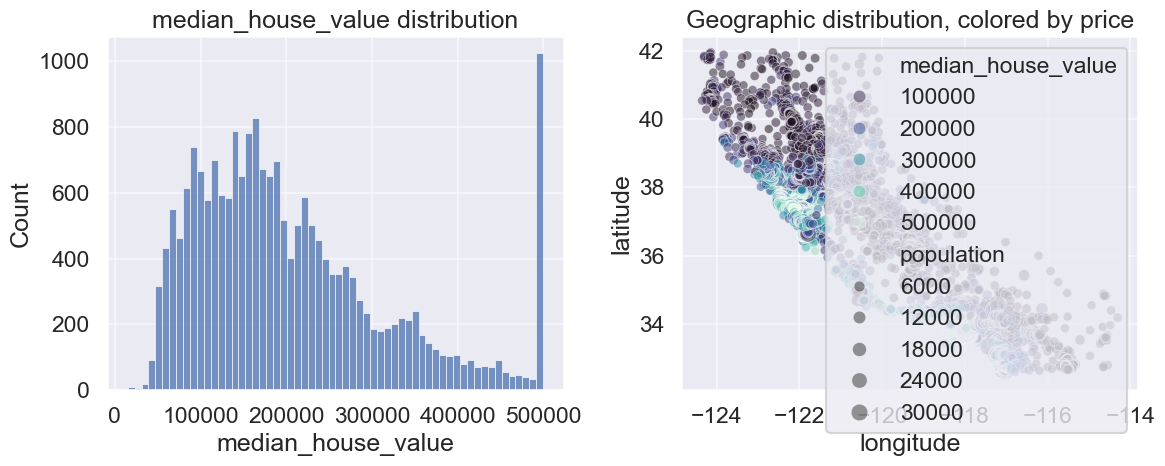

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(housing_data["median_house_value"], bins=60, ax=axes[0])
axes[0].set_title("median_house_value distribution")
sns.scatterplot(data=housing_data, x="longitude", y="latitude", hue="median_house_value",
                 palette="mako", size="population", alpha=0.5, ax=axes[1])
axes[1].set_title("Geographic distribution, colored by price")
plt.tight_layout()
plt.show()

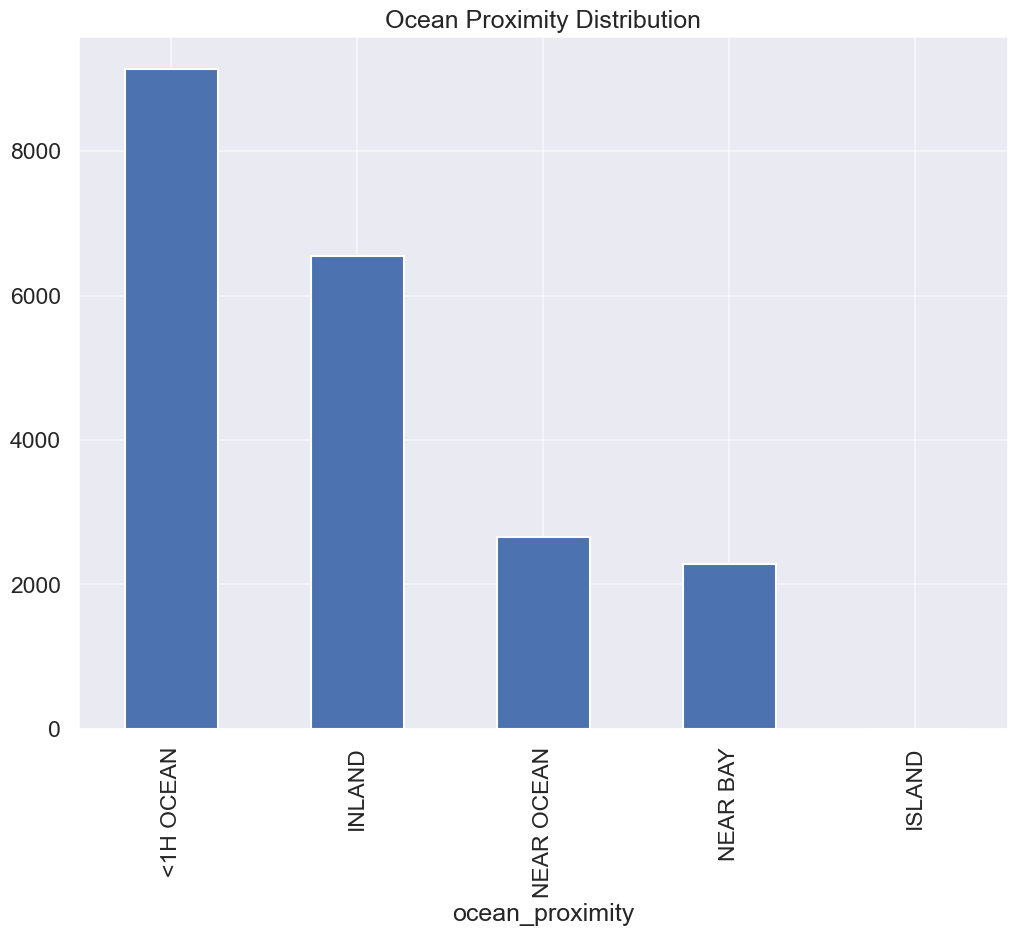

In [11]:
housing_data["ocean_proximity"].value_counts().plot(kind="bar")
plt.title("Ocean Proximity Distribution")
plt.show()

In [12]:
housing_data["bedrooms_missing"] = housing_data["total_bedrooms"].isna()

print("Missing rate by ocean_proximity:")
print(housing_data.groupby("ocean_proximity")["bedrooms_missing"].mean())
print()

from scipy.stats import chi2_contingency
tab = pd.crosstab(housing_data["bedrooms_missing"], housing_data["ocean_proximity"])
chi2, p, dof, _ = chi2_contingency(tab)
print(f"chi2={chi2:.3f}, p={p:.3f}")
print()

for col in ["housing_median_age", "total_rooms", "population", "households", "median_income", "median_house_value"]:
    miss_mean = housing_data.loc[housing_data["bedrooms_missing"], col].mean()
    obs_mean = housing_data.loc[~housing_data["bedrooms_missing"], col].mean()
    print(f"{col}: mean(missing)={miss_mean:.2f} vs mean(observed)={obs_mean:.2f}")

print()
print("corr(total_rooms, total_bedrooms) among observed rows:",
      housing_data.loc[~housing_data['bedrooms_missing'], 'total_rooms'].corr(housing_data.loc[~housing_data['bedrooms_missing'], 'total_bedrooms']))

Missing rate by ocean_proximity:
ocean_proximity
<1H OCEAN    0.01
INLAND       0.01
ISLAND       0.00
NEAR BAY     0.01
NEAR OCEAN   0.01
Name: bedrooms_missing, dtype: float64

chi2=3.808, p=0.433

housing_median_age: mean(missing)=29.27 vs mean(observed)=28.63
total_rooms: mean(missing)=2562.60 vs mean(observed)=2636.50
population: mean(missing)=1477.77 vs mean(observed)=1424.95
households: mean(missing)=510.02 vs mean(observed)=499.43
median_income: mean(missing)=3.82 vs mean(observed)=3.87
median_house_value: mean(missing)=206007.28 vs mean(observed)=206864.41

corr(total_rooms, total_bedrooms) among observed rows: 0.9303795046865075


In [13]:
housing_data = housing_data.drop(columns=["bedrooms_missing"], errors="ignore")
housing_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.00,880.00,129.00,322.00,126.00,8.33,452600.00,NEAR BAY
1,-122.22,37.86,21.00,7099.00,1106.00,2401.00,1138.00,8.30,358500.00,NEAR BAY
2,-122.24,37.85,52.00,1467.00,190.00,496.00,177.00,7.26,352100.00,NEAR BAY
3,-122.25,37.85,52.00,1274.00,235.00,558.00,219.00,5.64,341300.00,NEAR BAY
4,-122.25,37.85,52.00,1627.00,280.00,565.00,259.00,3.85,342200.00,NEAR BAY
